# Model interpretation for Visual Question Answering


In this notebook we demonstrate how to apply model interpretability algorithms from captum library on VQA models. More specifically we explain model predictions by applying integrated gradients on a small sample of image-question pairs. More details about Integrated gradients can be found in the original paper: https://arxiv.org/pdf/1703.01365.pdf

As a reference VQA model we use the following open source implementation:
https://github.com/Cyanogenoid/pytorch-vqa
  
  **Note:** Before running this tutorial, please install the `torchvision`, `PIL`, and `matplotlib` packages.

In [1]:
import os, sys

# Replace <PROJECT-DIR> placeholder with your project directory path
PROJECT_DIR = '/home/jky/xai-vdoc-retrieval-benchmark'

# Clone PyTorch VQA project from: https://github.com/Cyanogenoid/pytorch-vqa and add to your filepath
sys.path.append(os.path.realpath(f"{PROJECT_DIR}/pytorch-vqa"))

# Clone PyTorch Resnet model from: https://github.com/Cyanogenoid/pytorch-resnet and add to your filepath
# We can also use standard resnet model from torchvision package, however the model from `pytorch-resnet` 
# is slightly different from the original resnet model and performs better on this particular VQA task
sys.path.append(os.path.realpath(f"{PROJECT_DIR}/pytorch-resnet"))


In [2]:
import threading
import numpy as np

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import resnet  # from pytorch-resnet

import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import LinearSegmentedColormap

from model import Net, apply_attention, tile_2d_over_nd # from pytorch-vqa
from utils import get_transform # from pytorch-vqa

from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    LayerIntegratedGradients,
    TokenReferenceBase,
    configure_interpretable_embedding_layer,
    remove_interpretable_embedding_layer,
    visualization
)
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Loading VQA model

VQA model can be downloaded from: 
https://github.com/Cyanogenoid/pytorch-vqa/releases/download/v1.0/2017-08-04_00.55.19.pth

In [4]:
saved_state = torch.load('models/2017-08-04_00.55.19.pth', map_location=device)

# reading vocabulary from saved model
vocab = saved_state['vocab']

# reading word tokens from saved model
token_to_index = vocab['question']

# reading answers from saved model
answer_to_index = vocab['answer']

num_tokens = len(token_to_index) + 1

# reading answer classes from the vocabulary
answer_words = ['unk'] * len(answer_to_index)
for w, idx in answer_to_index.items():
    answer_words[idx]=w


Loads predefined VQA model and sets it to eval mode.
`device_ids` contains a list of GPU ids which are used for paralelization supported by `DataParallel`

In [5]:
vqa_net = torch.nn.DataParallel(Net(num_tokens))
vqa_net.load_state_dict(saved_state['weights'])
vqa_net.to(device)
vqa_net.eval()

/home/jky/xai-vdoc-retrieval-benchmark/pytorch-vqa/model.py:86: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  init.xavier_uniform(self.embedding.weight)
/home/jky/xai-vdoc-retrieval-benchmark/pytorch-vqa/model.py:44: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  init.xavier_uniform(m.weight)


DataParallel(
  (module): Net(
    (text): TextProcessor(
      (embedding): Embedding(15193, 300, padding_idx=0)
      (drop): Dropout(p=0.5, inplace=False)
      (tanh): Tanh()
      (lstm): LSTM(300, 1024)
    )
    (attention): Attention(
      (v_conv): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (q_lin): Linear(in_features=1024, out_features=512, bias=True)
      (x_conv): Conv2d(512, 2, kernel_size=(1, 1), stride=(1, 1))
      (drop): Dropout(p=0.5, inplace=False)
      (relu): ReLU(inplace=True)
    )
    (classifier): Classifier(
      (drop1): Dropout(p=0.5, inplace=False)
      (lin1): Linear(in_features=5120, out_features=1024, bias=True)
      (relu): ReLU()
      (drop2): Dropout(p=0.5, inplace=False)
      (lin2): Linear(in_features=1024, out_features=3000, bias=True)
    )
  )
)

Converting string question into a tensor. `encode_question` function is similar to original implementation of `encode_question` method in pytorch-vqa source code.
https://github.com/Cyanogenoid/pytorch-vqa/blob/master/data.py#L110



In [6]:
def encode_question(question):
    """ Turn a question into a vector of indices and a question length """
    question_arr = question.lower().split()
    vec = torch.zeros(len(question_arr), device=device).long()
    for i, token in enumerate(question_arr):
        index = token_to_index.get(token, 0)
        vec[i] = index
    return vec, torch.tensor(len(question_arr), device=device)


## Defining end-to-end VQA model

Original saved model does not have image network's (resnet's) layers attached to it. We attach it in the below cell using forward-hook. The rest of the model is identical to the original definition of the model: https://github.com/Cyanogenoid/pytorch-vqa/blob/master/model.py#L48

In [7]:
class ResNetLayer4(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.r_model = resnet.resnet152(pretrained=True)
        self.r_model.eval()
        self.r_model.to(device)

        self.buffer = {}
        lock = threading.Lock()

        # Since we only use the output of the 4th layer from the resnet model and do not
        # need to do forward pass all the way to the final layer we can terminate forward
        # execution in the forward hook of that layer after obtaining the output of it.
        # For that reason, we can define a custom Exception class that will be used for
        # raising early termination error.
        def save_output(module, input, output):
            with lock:
                self.buffer[output.device] = output

        self.r_model.layer4.register_forward_hook(save_output)

    def forward(self, x):
        self.r_model(x)          
        return self.buffer[x.device]

class VQA_Resnet_Model(Net):
    def __init__(self, embedding_tokens):
        super().__init__(embedding_tokens)
        self.resnet_layer4 = ResNetLayer4()
    
    def forward(self, v, q, q_len):
        q = self.text(q, list(q_len.data))
        v = self.resnet_layer4(v)

        v = v / (v.norm(p=2, dim=1, keepdim=True).expand_as(v) + 1e-8)

        a = self.attention(v, q)
        v = apply_attention(v, a)

        combined = torch.cat([v, q], dim=1)
        answer = self.classifier(combined)
        return answer


In order to explain text features, we must let integrated gradients attribute on the embeddings, not the indices. The reason for this is simply due to Integrated Gradients being a gradient-based attribution method, as we are unable to compute gradients with respect to integers.

Hence, we have two options:
1. "Patch" the model's embedding layer and corresponding inputs. To patch the layer, use the `configure_interpretable_embedding_layer`^ method, which will wrap the associated layer you give it, with an identity function. This identity function accepts an embedding and outputs an embedding. You can patch the inputs, i.e. obtain the embedding for a set of indices, with `model.wrapped_layer.indices_to_embeddings(indices)`.
2. Use the equivalent layer attribution algorithm (`LayerIntegratedGradients` in our case) with the utility class `ModelInputWrapper`. The `ModelInputWrapper` will wrap your model and feed all it's inputs to seperate layers; allowing you to use layer attribution methods on inputs. You can access the associated layer for input named `"foo"` via the `ModuleDict`: `wrapped_model.input_maps["foo"]`.

^ NOTE: For option (1), after finishing interpretation it is important to call `remove_interpretable_embedding_layer` which removes the Interpretable Embedding Layer that we added for interpretation purposes and sets the original embedding layer back in the model.

Below I am using the `USE_INTEPRETABLE_EMBEDDING_LAYER` flag to do option (1) if it is True, otherwise (2) if it is False. Generally it is reccomended to do option (2) since this option is much more flexible and easy to use. The reason it is more flexible is it allows your model to do any sort of preprocessing to the indices tensor. It's easier to use since you don't have to touch your inputs.

In [8]:
USE_INTEPRETABLE_EMBEDDING_LAYER = True  # set to True for option (1)

In [9]:
image_features = image_to_features(img).requires_grad_().to(device)
for question, target in zip(questions, targets):
    q, q_len = encode_question(question)
    
    # generate reference for each sample
    q_reference_indices = token_reference.generate_reference(q_len.item(), device=device).unsqueeze(0)

    inputs = (q.unsqueeze(0), q_len.unsqueeze(0))
    if USE_INTEPRETABLE_EMBEDDING_LAYER:
        q_input_embedding = interpretable_embedding.indices_to_embeddings(q).unsqueeze(0)
        q_reference_baseline = interpretable_embedding.indices_to_embeddings(q_reference_indices).to(device)

        inputs = (image_features, q_input_embedding)
        baselines = (image_features * 0.0, q_reference_baseline)
        
    else:            
        inputs = (image_features, q.unsqueeze(0))
        baselines = (image_features * 0.0, q_reference_indices)
        
    ans = vqa_resnet(*inputs, q_len.unsqueeze(0))
        
    # Make a prediction. The output of this prediction will be visualized later.
    pred, answer_idx = F.softmax(ans, dim=1).data.cpu().max(dim=1)

    attributions = attr.attribute(inputs=inputs,
                                baselines=baselines,
                                target=answer_idx,
                                additional_forward_args=q_len.unsqueeze(0),
                                n_steps=30)
        
    # Visualize text attributions
    text_attributions_norm = attributions[1].sum(dim=2).squeeze(0).norm()
    vis_data_records = [visualization.VisualizationDataRecord(
                            attributions[1].sum(dim=2).squeeze(0) / text_attributions_norm,
                            pred[0].item(),
                            answer_words[ answer_idx ],
                            answer_words[ answer_idx ],
                            target,
                            attributions[1].sum(),       
                            question.split(),
                            0.0)]
    visualization.visualize_text(vis_data_records)

    # visualize image attributions
    original_im_mat = np.transpose(original_image.cpu().detach().numpy(), (1, 2, 0))
    attributions_img = np.transpose(attributions[0].squeeze(0).cpu().detach().numpy(), (1, 2, 0))
    
    visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                                ["original_image", "heat_map"], ["all", "absolute_value"], 
                                                titles=["Original Image", "Attribution Magnitude"],
                                                cmap=default_cmap,
                                                show_colorbar=True)
    print('Text Contributions: ', attributions[1].sum().item())
    print('Image Contributions: ', attributions[0].sum().item())
    print('Total Contribution: ', attributions[0].sum().item() + attributions[1].sum().item())


NameError: name 'image_to_features' is not defined

Updating weights from the saved model and removing the old model from the memory. And wrap the model with `ModelInputWrapper`.

In [9]:
vqa_resnet = VQA_Resnet_Model(vqa_net.module.text.embedding.num_embeddings)

# wrap the inputs into layers incase we wish to use a layer method
vqa_resnet = ModelInputWrapper(vqa_resnet)

# `device_ids` contains a list of GPU ids which are used for paralelization supported by `DataParallel`
vqa_resnet = torch.nn.DataParallel(vqa_resnet)

# saved vqa model's parameters
partial_dict = vqa_net.state_dict()

state = vqa_resnet.module.state_dict()
state.update(partial_dict)
vqa_resnet.module.load_state_dict(state)

vqa_resnet.to(device)
vqa_resnet.eval()

# This is original VQA model without resnet. Removing it, since we do not need it
del vqa_net


Patch the model's embedding layer if we're doing option (1)

In [10]:
if USE_INTEPRETABLE_EMBEDDING_LAYER:
    interpretable_embedding = configure_interpretable_embedding_layer(vqa_resnet, 'module.module.text.embedding')

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/captum/attr/_models/base.py:206: UserWarning: In order to make embedding layers more interpretable they will be replaced with an interpretable embedding layer which wraps the original embedding layer and takes word embedding vectors as inputs of the forward function. This allows us to generate baselines for word embeddings and compute attributions for each embedding dimension. The original embedding layer must be set back by calling `remove_interpretable_embedding_layer` function after model interpretation is finished. 
  warnings.warn(


Below function will help us to transform and image into a tensor.

In [11]:
image_size = 448  # scale image to given size and center
central_fraction = 1.0

transform = get_transform(image_size, central_fraction=central_fraction)
    
def image_to_features(img):
    img_transformed = transform(img)
    img_batch = img_transformed.unsqueeze(0).to(device)
    return img_batch

Creating reference aka baseline / background for questions. This is specifically necessary for baseline-based model interpretability algorithms. In this case for integrated gradients. More details can be found in the original paper: https://arxiv.org/pdf/1703.01365.pdf

In [12]:
PAD_IND = token_to_index['pad']
token_reference = TokenReferenceBase(reference_token_idx=PAD_IND)

In [13]:
# this is necessary for the backpropagation of RNNs models in eval mode
torch.backends.cudnn.enabled=False

Creating an instance of layer integrated gradients for option (2); otherwise create an instance of integrated gradients for option (1). Both are equivalent methods to interpret the model's outputs.

In [14]:
if USE_INTEPRETABLE_EMBEDDING_LAYER:
    attr = IntegratedGradients(vqa_resnet)
else:
    attr = LayerIntegratedGradients(vqa_resnet, [vqa_resnet.module.input_maps["v"], vqa_resnet.module.module.text.embedding])

Defining default cmap that will be used for image visualizations 

In [15]:
# default_cmap = LinearSegmentedColormap.from_list('custom blue', 
#                                                  [(0, '#ffffff'),
#                                                   (0.25, '#252b36'),
#                                                   (1, '#000000')], N=256)


default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

Defining a few test images for model intepretation purposes

In [16]:
images = ['./img/siamese.jpg',
          './img/elephant.jpg',
          './img/zebra.jpg']

In [17]:
def vqa_resnet_interpret(image_filename, questions, targets):
    img = Image.open(image_filename).convert('RGB')
    original_image = transforms.Compose([transforms.Resize(int(image_size / central_fraction)),
                                   transforms.CenterCrop(image_size), transforms.ToTensor()])(img) 
    
    image_features = image_to_features(img).requires_grad_().to(device)
    for question, target in zip(questions, targets):
        q, q_len = encode_question(question)
        
        # generate reference for each sample
        q_reference_indices = token_reference.generate_reference(q_len.item(), device=device).unsqueeze(0)

        inputs = (q.unsqueeze(0), q_len.unsqueeze(0))
        if USE_INTEPRETABLE_EMBEDDING_LAYER:
            q_input_embedding = interpretable_embedding.indices_to_embeddings(q).unsqueeze(0)
            q_reference_baseline = interpretable_embedding.indices_to_embeddings(q_reference_indices).to(device)

            inputs = (image_features, q_input_embedding)
            baselines = (image_features * 0.0, q_reference_baseline)
            
        else:            
            inputs = (image_features, q.unsqueeze(0))
            baselines = (image_features * 0.0, q_reference_indices)
            
        ans = vqa_resnet(*inputs, q_len.unsqueeze(0))
            
        # Make a prediction. The output of this prediction will be visualized later.
        pred, answer_idx = F.softmax(ans, dim=1).data.cpu().max(dim=1)

        attributions = attr.attribute(inputs=inputs,
                                    baselines=baselines,
                                    target=answer_idx,
                                    additional_forward_args=q_len.unsqueeze(0),
                                    n_steps=30)
            
        # Visualize text attributions
        text_attributions_norm = attributions[1].sum(dim=2).squeeze(0).norm()
        vis_data_records = [visualization.VisualizationDataRecord(
                                attributions[1].sum(dim=2).squeeze(0) / text_attributions_norm,
                                pred[0].item(),
                                answer_words[ answer_idx ],
                                answer_words[ answer_idx ],
                                target,
                                attributions[1].sum(),       
                                question.split(),
                                0.0)]
        visualization.visualize_text(vis_data_records)

        # visualize image attributions
        original_im_mat = np.transpose(original_image.cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[0].squeeze(0).cpu().detach().numpy(), (1, 2, 0))
        
        visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                                    ["original_image", "heat_map"], ["all", "all"], 
                                                    titles=["Original Image", "Attribution Magnitude"],
                                                    cmap=default_cmap,
                                                    show_colorbar=True)
        print('Text Contributions: ', attributions[1].sum().item())
        print('Image Contributions: ', attributions[0].sum().item())
        print('Total Contribution: ', attributions[0].sum().item() + attributions[1].sum().item())
        return attributions

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
elephant,elephant (0.55),elephant,4.76,what is on the picture


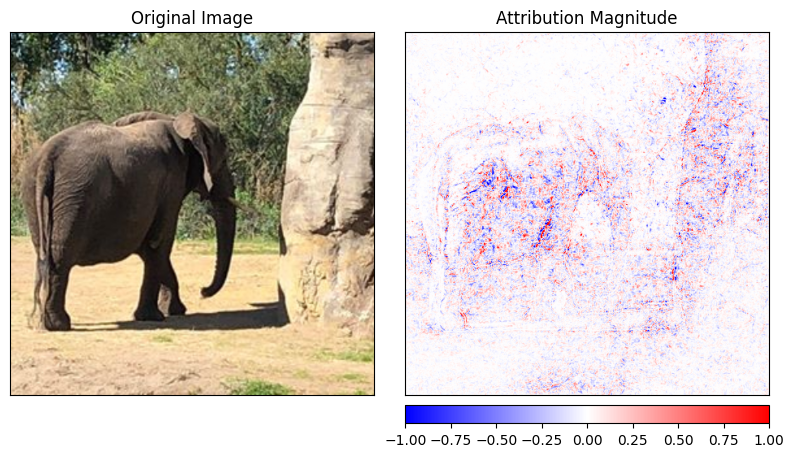

Text Contributions:  4.755358695983887
Image Contributions:  17.973304748535156
Total Contribution:  22.728663444519043


In [18]:
# the index of image in the test set. Please, change it if you want to play with different test images/samples.
image_idx = 1 # elephant
attributions = vqa_resnet_interpret(images[image_idx], [
                    "what is on the picture",
                    "what color is the elephant",
                    "where is the elephant"
                ], ['elephant', 'gray', 'zoo'])

In [20]:
attributions[0].shape

torch.Size([1, 3, 448, 448])

In [21]:
text_attributions_norm = attributions[1].sum(dim=2).squeeze(0).norm()
viz_text_attr = attributions[1].sum(dim=2).squeeze(0) / text_attributions_norm

In [22]:
viz_text_attr

tensor([-0.0702,  0.7349,  0.3151,  0.0246,  0.5959], device='cuda:0',
       grad_fn=<DivBackward0>)

In [23]:
question = "what is on the picture"
target = "elephant"
q, q_len = encode_question(question)
mask_token_id = PAD_IND

In [24]:
img = Image.open(images[image_idx]).convert('RGB')
image_features = image_to_features(img).requires_grad_().to(device)

q_input_embedding = interpretable_embedding.indices_to_embeddings(q).unsqueeze(0)
inputs = (image_features, q_input_embedding)

In [25]:
q_input_embedding

tensor([[[ 0.0103, -0.0639,  0.0070,  ...,  0.0420,  0.1166, -0.0563],
         [-0.0759, -0.0594, -0.0232,  ...,  0.0313,  0.0097,  0.1141],
         [ 0.0272, -0.0928,  0.0599,  ...,  0.0644,  0.0492,  0.1327],
         [ 0.0033,  0.0050, -0.0338,  ...,  0.0310,  0.0190,  0.0207],
         [ 0.0394, -0.1276, -0.0807,  ..., -0.0428,  0.0815,  0.0014]]],
       device='cuda:0', grad_fn=<UnsqueezeBackward0>)

In [26]:
outs = vqa_resnet(*inputs, q_len.unsqueeze(0))

In [30]:
# Make a prediction. The output of this prediction will be visualized later.
# pred, answer_idx = F.softmax(outs, dim=1).data.cpu().max(dim=1)
probs = F.softmax(outs, dim=1)
pred, answer_idx = probs.max(dim=1)   


## Token perturbation tests

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor
from typing import Callable, Sequence, Dict, Any, Optional


@torch.no_grad()
def eval_sample_perturbation(
    model: torch.nn.Module,
    img: Tensor,                     # (C, H, W)
    attribution: Tensor,             # same spatial shape: (C, H, W) or (H, W)
    target: int,                     # integer class id
    perturbation_steps: Sequence[float],
    normalize_fn: Callable[[Tensor], Tensor],
    device: Optional[torch.device] = None,
    negate_saliency: bool = False,
    base_size: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Evaluate perturbation metrics for a *single* sample.

    Parameters
    ----------
    model : nn.Module
        Classifier returning logits of shape (B, num_classes).
    img : Tensor
        Input image, shape (C, H, W), unnormalized.
    attribution : Tensor
        Saliency / attribution map aligned with img. Can be (C, H, W) or (H, W).
    target : int
        Ground truth class index.
    perturbation_steps : list or tuple of float
        Fractions of pixels to mask (e.g. [0.1, 0.2, ..., 0.9]).
        If `base_size` is None, base_size defaults to H * W.
    normalize_fn : Callable
        Function that takes a batch of images (B, C, H, W) and returns
        normalized images for the model.
    device : torch.device, optional
        Device on which to run the model. If None, inferred from model params.
    negate_saliency : bool, default False
        If True, uses -attribution (e.g. to test "least important first").
    base_size : int, optional
        Base size used to compute k = int(base_size * step). If None, H*W.

    Returns
    -------
    dict with keys:
        - "baseline_correct": int (0/1)
        - "baseline_dissimilarity": float
        - "perturbation_steps": list[float]
        - "prob_diff": np.ndarray, shape (S,)
        - "logit_diff": np.ndarray, shape (S,)
        - "correct_perturb": np.ndarray, shape (S,)
        - "dissimilarity_perturb": np.ndarray, shape (S,)
    """
    model.eval()

    if device is None:
        device = next(model.parameters()).device

    img = img.to(device)
    attribution = attribution.to(device)
    target_tensor = torch.tensor([target], device=device)

    # Ensure batch dimension
    img_batch = img.unsqueeze(0)  # (1, C, H, W)
    B, C, H, W = img_batch.shape
    assert B == 1, "eval_sample_perturbation is designed for a single sample."

    # ----- prepare saliency -----
    # If (H, W), add channel dim; then flatten spatial dims.
    if attribution.dim() == 2:
        vis = attribution.unsqueeze(0)  # (1, H, W)
    elif attribution.dim() == 3:
        # Either (C, H, W) or (1, H, W). We don't care: flatten everything.
        vis = attribution
    else:
        raise ValueError("attribution must be (H, W) or (C, H, W)")

    if negate_saliency:
        vis = -vis

    vis_flat = vis.view(-1)  # (C*H*W) or (H*W)

    # base_size: how many positions we consider as "pixels"
    if base_size is None:
        base_size = H * W

    # ----- baseline forward pass -----
    norm_img = normalize_fn(img_batch.clone())           # (1, C, H, W)
    logits = model(norm_img)                             # (1, num_classes)
    probs = F.softmax(logits, dim=1)                     # (1, num_classes)

    # Top-1 prediction
    pred_logits, pred_classes = logits.max(dim=1)        # (1,), (1,)
    pred_probs = probs.max(dim=1).values                 # (1,)

    baseline_pred_logit = pred_logits.item()
    baseline_pred_prob = pred_probs.item()
    baseline_correct = int(pred_classes.item() == target)

    # Dissimilarity: log(target_prob / second_best_prob)
    target_probs = probs[0, target_tensor]               # scalar
    top2_probs = probs[0].topk(2).values                 # (2,)
    second_prob = top2_probs[1]
    baseline_dissimilarity = float(torch.log(target_probs / second_prob).item())

    # ----- arrays to store per-perturbation metrics -----
    S = len(perturbation_steps)
    prob_diff = np.zeros(S, dtype=np.float32)
    logit_diff = np.zeros(S, dtype=np.float32)
    correct_perturb = np.zeros(S, dtype=np.float32)
    dissimilarity_perturb = np.zeros(S, dtype=np.float32)

    # ----- perturbation loop -----
    num_pixels = H * W  # spatial positions
    for i, step in enumerate(perturbation_steps):
        # number of pixels to mask
        k = int(round(base_size * step))
        k = max(1, min(k, num_pixels))

        # pick top-k positions according to flattened attribution
        _, idx = torch.topk(vis_flat, k, dim=-1)  # (k,)

        # clone image and zero-out those positions across channels
        perturbed = img_batch.clone().view(1, C, -1)     # (1, C, H*W)

        # expand indices to channels
        idx_expanded = idx.unsqueeze(0).unsqueeze(0).expand(1, C, k)  # (1, C, k)
        perturbed.scatter_(dim=2, index=idx_expanded, src=torch.zeros_like(perturbed[:, :, :k]))
        perturbed = perturbed.view(1, C, H, W)

        # forward on perturbed image
        norm_perturbed = normalize_fn(perturbed)
        out = model(norm_perturbed)
        probs_p = F.softmax(out, dim=1)

        # max prob / logit
        pert_logits, pert_classes = out.max(dim=1)
        pert_probs = probs_p.max(dim=1).values

        # store differences vs baseline
        prob_diff[i] = float((pert_probs - pred_probs).item())
        logit_diff[i] = float((pert_logits - pred_logits).item())

        # accuracy after perturbation
        correct_perturb[i] = float(pert_classes.item() == target)

        # dissimilarity after perturbation
        t_probs_p = probs_p[0, target_tensor]
        top2_probs_p = probs_p[0].topk(2).values
        second_prob_p = top2_probs_p[1]
        dissim_p = torch.log(t_probs_p / second_prob_p).item()
        dissimilarity_perturb[i] = float(dissim_p)

    return {
        "baseline_correct": baseline_correct,
        "baseline_dissimilarity": baseline_dissimilarity,
        "perturbation_steps": list(perturbation_steps),
        "prob_diff": prob_diff,                  # (S,)
        "logit_diff": logit_diff,                # (S,)
        "correct_perturb": correct_perturb,      # (S,)
        "dissimilarity_perturb": dissimilarity_perturb,  # (S,)
    }


@torch.no_grad()
def eval_token_perturbation(
    model: torch.nn.Module,
    input_ids: Tensor,                # (L,)
    attribution: Tensor,              # (L,)
    target: int,                      # class id
    perturbation_steps: Sequence[float],
    pad_token_id: int,
    mask_token_id: Optional[int] = None,
    device: Optional[torch.device] = None,
    negate_saliency: bool = False,
) -> Dict[str, Any]:
    """
    Single-sample token perturbation evaluation.

    Parameters
    ----------
    model : nn.Module
        Text classifier (HF-style). Must accept input_ids, attention_mask.
    input_ids : Tensor
        Token IDs, shape (L,).
    attribution : Tensor
        Token attributions, shape (L,).
    target : int
        Ground-truth class index.
    perturbation_steps : sequence of float
        Fractions of tokens to perturb, e.g. [0.1, 0.2, ..., 0.9].
        Each step 's' means we mask floor(s * L) tokens.
    pad_token_id : int
        ID used for padding tokens.
    mask_token_id : int, optional
        If provided, we replace selected tokens with this ID.
        If None, we fall back to pad_token_id.
    device : torch.device, optional
        Device to run on. If None, inferred from model.
    negate_saliency : bool, default False
        If True, use -attribution (e.g. to perturb least-important tokens first).

    Returns
    -------
    dict with keys:
        - "baseline_correct": int (0/1)
        - "baseline_dissimilarity": float
        - "perturbation_steps": list[float]
        - "prob_diff": np.ndarray, shape (S,)
        - "logit_diff": np.ndarray, shape (S,)
        - "correct_perturb": np.ndarray, shape (S,)
        - "dissimilarity_perturb": np.ndarray, shape (S,)
    """
    model.eval()

    if device is None:
        device = next(model.parameters()).device

    input_ids = input_ids.to(device)
    attribution = attribution.to(device)
    target_tensor = torch.tensor([target], device=device)

    # use mask_token if given, else pad_token
    if mask_token_id is None:
        mask_token_id = pad_token_id

    # add batch dimension
    input_ids_batch = input_ids.unsqueeze(0)  # (1, L)
    L = input_ids_batch.size(1)

    # attention mask: 1 for non-pad tokens
    attention_mask = (input_ids_batch != pad_token_id).long()

    # ----- helper to extract logits from HF / plain model -----
    def _get_logits(**kwargs) -> Tensor:
        out = model(**kwargs)
        if hasattr(out, "logits"):
            return out.logits
        return out

    # ----- baseline forward -----
    logits = _get_logits(input_ids=input_ids_batch, attention_mask=attention_mask)  # (1, C)
    probs = F.softmax(logits, dim=-1)                                               # (1, C)

    baseline_pred_logits, baseline_pred_classes = logits.max(dim=1)                 # (1,)
    baseline_pred_probs = probs.max(dim=1).values                                   # (1,)

    baseline_pred_logit = baseline_pred_logits.item()
    baseline_pred_prob = baseline_pred_probs.item()
    baseline_correct = int(baseline_pred_classes.item() == target)

    # dissimilarity: log(p(target) / p(second_best))
    target_probs = probs[0,  ]                  # scalar
    top2_probs = probs[0].topk(2).values                    # (2,)
    second_prob = top2_probs[1]
    baseline_dissimilarity = float(torch.log(target_probs / second_prob).item())

    # ----- saliency vector -----
    sal = attribution.clone()
    if negate_saliency:
        sal = -sal
    # (L,)

    S = len(perturbation_steps)
    prob_diff = np.zeros(S, dtype=np.float32)
    logit_diff = np.zeros(S, dtype=np.float32)
    correct_perturb = np.zeros(S, dtype=np.float32)
    dissimilarity_perturb = np.zeros(S, dtype=np.float32)

    # ----- perturbation loop -----
    for i, step in enumerate(perturbation_steps):
        # number of tokens to perturb
        k = int(round(step * L))
        k = max(1, min(k, L))

        # indices of top-k tokens
        _, idx = torch.topk(sal, k, dim=-1)  # (k,)

        # create perturbed input ids
        perturbed_ids = input_ids_batch.clone()  # (1, L)
        perturbed_ids[0, idx] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            perturbed_mask[0, idx] = 0

        # forward perturbed
        out = _get_logits(input_ids=perturbed_ids, attention_mask=perturbed_mask)
        probs_p = F.softmax(out, dim=-1)

        pert_logits, pert_classes = out.max(dim=1)
        pert_probs = probs_p.max(dim=1).values

        # store deltas vs baseline
        prob_diff[i] = float((pert_probs - baseline_pred_probs).item())
        logit_diff[i] = float((pert_logits - baseline_pred_logits).item())

        # accuracy after perturbation
        correct_perturb[i] = float(pert_classes.item() == target)

        # dissimilarity after perturbation
        t_probs_p = probs_p[0, target_tensor]
        top2_probs_p = probs_p[0].topk(2).values
        second_prob_p = top2_probs_p[1]
        dissim_p = torch.log(t_probs_p / second_prob_p).item()
        dissimilarity_perturb[i] = float(dissim_p)

    return {
        "baseline_correct": baseline_correct,
        "baseline_dissimilarity": baseline_dissimilarity,
        "perturbation_steps": list(perturbation_steps),
        "prob_diff": prob_diff,                  # (S,)
        "logit_diff": logit_diff,                # (S,)
        "correct_perturb": correct_perturb,      # (S,)
        "dissimilarity_perturb": dissimilarity_perturb,  # (S,)
    }


## HF VQA

In [1]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [2]:
from transformers import ViltProcessor, ViltForQuestionAnswering
import requests
from PIL import Image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
text = "How many cats are there?"

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
model = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa")


In [3]:
# prepare inputs
encoding = processor(image, text, return_tensors="pt")

In [5]:
# forward pass
outputs = model(**encoding)
logits = outputs.logits
idx = logits.argmax(-1).item()
print("Predicted answer:", model.config.id2label[idx])

Predicted answer: 2


In [15]:
idx

17

In [8]:
import torch
from einops import rearrange

torch.cuda.empty_cache()

In [5]:
from abc import abstractmethod
from typing import Union
from torch import nn

class HF_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        return self.hf_model.vilt.embeddings.text_embeddings.word_embeddings

    def forward(self, text_embeds, pixel_values, pixel_mask,
                attention_mask, token_type_ids):
        outs = self.hf_model(inputs_embeds = text_embeds,
                             pixel_values=pixel_values,
                             attention_mask=attention_mask,
                             pixel_mask=pixel_mask,
                             token_type_ids=token_type_ids,
                             )
        return outs.logits
    
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "HF_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self


In [6]:
model_wrapper = HF_Wrapper(model, processor)
attr_hf = IntegratedGradients(model_wrapper)

In [7]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [9]:
def get_attributions_plot(inpts, target, model,
                          processor, attr_hf,
                          use_baselines=True,
                          plot=True):

    input_ids = inpts["input_ids"]
    pixel_values = inpts["pixel_values"]
    pixel_mask = inpts["pixel_mask"]
    token_type_ids = inpts["token_type_ids"]
    attention_mask = inpts["attention_mask"]

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds, pixel_values.requires_grad_())
    captum_add_forward = (pixel_mask, attention_mask, token_type_ids)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    captum_args = captum_forward + captum_add_forward
    logits = model_wrapper(*captum_args)
    pred, idx = logits.max(dim=1)

    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=idx,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=idx,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    # Visualize text attributions
    text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
    text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm
    

    if plot:
        # Visualize text attributions
        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            pred[0].item(),
                            model.hf_model.config.id2label[idx.item()],
                            model.hf_model.config.id2label[idx.item()],
                            target,
                            attributions[0].sum(),       
                            text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)

        # visualize image attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                                    ["original_image", "heat_map"], ["all", "all"], 
                                                    titles=["Original Image", "Attribution Magnitude"],
                                                    cmap=default_cmap,
                                                    show_colorbar=True)
    

    attributions_img = rearrange(attributions[1].cpu().detach(), 'b c h w -> b h w c')
    attributions_img = attributions_img.sum(axis=-1)

    attributions_text = attributions[0].sum(dim=2).cpu().detach()
        
    return attributions_img, attributions_text


In [12]:
inpts = processor(image, text, return_tensors="pt")
target = "2"
model_wrapper = HF_Wrapper(model, processor)
#attr_hf = IntegratedGradients(model_wrapper)
ixg_attr = InputXGradient(model_wrapper)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,2 (1.99),2,5.62,How many cats are there?


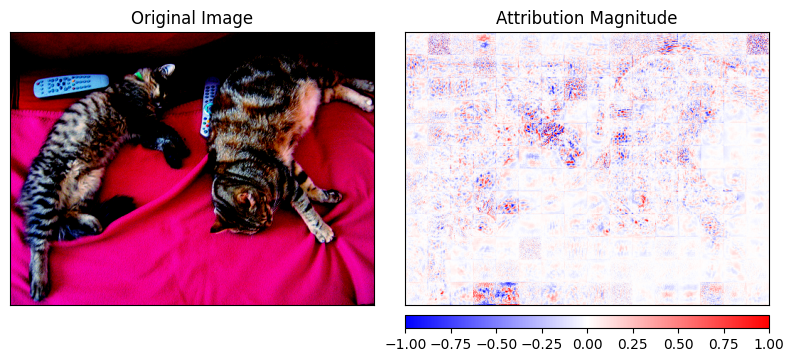

In [13]:
attributions = get_attributions_plot(inpts, target, model_wrapper,
                                    processor, attr_hf,
                                    use_baselines=False,
                                    plot=True)

In [25]:
attributions_img = attributions[0]
attributions_text = attributions[1]

In [16]:
attributions_text.shape

torch.Size([1, 8])

In [17]:
model_wrapper.hf_model.eval()

fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
fractions = np.array(sorted(set(fractions)), dtype=np.float32)


In [18]:
fractions

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5], dtype=float32)

In [19]:
mask_token_id = processor.tokenizer.pad_token_id
mask_token_id

0

In [59]:
order_asc = attributions_text.argsort(axis=1, descending=False)  # (B, L)

In [26]:
target = '2'
target_idx = model_wrapper.hf_model.config.label2id[target]

In [27]:
def eval_token_perturbation(model_wrapper, inpts,
                            target_idx,
                            token_attribution,
                            perturbation_steps,
                            mask_token_id,
                            pad_token_id,
                            descending=True,
                            ):
    input_ids = inpts["input_ids"]
    pixel_values = inpts["pixel_values"]
    pixel_mask = inpts["pixel_mask"]
    token_type_ids = inpts["token_type_ids"]
    attention_mask = inpts["attention_mask"]

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds, pixel_values.requires_grad_())
    captum_add_forward = (pixel_mask, attention_mask, token_type_ids)

    # Make a forward and predictions for the baselines
    captum_args = captum_forward + captum_add_forward
    baseline_logits = model_wrapper(*captum_args)
    baseline_probs = baseline_logits.sigmoid()
    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)


    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2)

    baseline_dissimilarity = float(torch.log(baseline_top_scores[0][0] / baseline_top_scores[0][1]).item())
    baseline_correct = int(baseline_top_ids[0][0].item() == target_idx)

    # Do the perturbations
    S = len(perturbation_steps)
    prob_diff = np.zeros(S, dtype=np.float32)
    logit_diff = np.zeros(S, dtype=np.float32)
    correct_perturb = np.zeros(S, dtype=np.float32)
    dissimilarity_perturb = np.zeros(S, dtype=np.float32)

    num_tokens = input_ids.shape[1]

    # ----- perturbation loop -----

    for i, step in enumerate(perturbation_steps):
        # number of tokens to perturb
        k = int(round(step * num_tokens))
        k = max(1, min(k, num_tokens))

        # indices of top-k tokens
        _, indices = torch.topk(token_attribution, k,
                            dim=-1, largest=descending)  # (k,)

        # create perturbed input ids
        perturbed_ids = input_ids.clone()  # (1, L)
        perturbed_ids[0, indices] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            perturbed_mask[0, indices] = 0

        perturbed_embeds = model_wrapper.text_embeddings_layer(perturbed_ids)

        captum_forward = (perturbed_embeds, pixel_values)
        captum_add_forward = (pixel_mask, perturbed_mask, token_type_ids)

        # perturbed forward and predictions
        captum_args = captum_forward + captum_add_forward
        logits_pert = model_wrapper(*captum_args)
        probs_pert = logits_pert.sigmoid()

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)
        pert_top_scores, _ = probs_pert.topk(2)


        # store deltas vs baseline
        # Probability delta
        prob_diff[i] = float((pert_top_scores[0][0] - baseline_top_scores[0][0]).item())

        # Logit delta
        logit_diff[i] = float((pert_max_logit - baseline_max_logit).item())

        # Confidence margin after perturbation
        pert_target_prob = probs_pert[0, target_idx]
        pert_dissimilarity = float(torch.log(pert_target_prob / pert_top_scores[0][1]).item())
        dissimilarity_perturb[i] = pert_dissimilarity

        # accuracy after perturbation
        pert_correct = int(pert_max_idx.item() == target_idx)
        correct_perturb[i] = pert_correct

        # dissimilarity after perturbation
        # t_probs_p = probs_p[0, target_tensor]
        # top2_probs_p = probs_p[0].topk(2).values
        # second_prob_p = top2_probs_p[1]
        # dissim_p = torch.log(t_probs_p / second_prob_p).item()
    return {
    "baseline_correct": baseline_correct,
    "baseline_dissimilarity": baseline_dissimilarity,
    "prob_diff": prob_diff,                  # (S,)
    "logit_diff": logit_diff,                # (S,)
    "correct_perturb": correct_perturb,      # (S,)
    "dissimilarity_perturb": dissimilarity_perturb,  # (S,)
}


In [28]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict


@torch.no_grad()
def eval_token_perturbation_batch(
    model_wrapper,
    inpts,
    target_idx: Tensor,          # (B,) tensor of class indices
    token_attribution: Tensor,   # (B, L) token-wise attribution scores
    perturbation_steps: Sequence[float],
    mask_token_id: int,
    pad_token_id: int,
    descending: bool = True,
) -> Dict[str, np.ndarray]:
    """
    Batch-level token perturbation evaluation for a VLM wrapper.

    Args
    ----
    model_wrapper: nn.Module
        Your wrapper with a forward like:
            model_wrapper(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids)
        and a `.text_embeddings_layer(input_ids)` method.
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, ...),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices for each sample.
    token_attribution: Tensor
        (B, L) attribution scores per token.
    perturbation_steps: list/tuple of float
        Fractions of tokens to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_token_id: int
        Token id that will replace perturbed tokens.
    pad_token_id: int
        Padding token id. If mask_token_id == pad_token_id,
        the attention mask is updated accordingly.
    descending: bool
        If True, mask most important tokens first (positive perturbation).
        If False, mask least important tokens first (negative perturbation).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device

    input_ids      = inpts["input_ids"].to(device)      # (B, L)
    pixel_values   = inpts["pixel_values"].to(device)
    pixel_mask     = inpts["pixel_mask"].to(device)
    token_type_ids = inpts["token_type_ids"].to(device)
    attention_mask = inpts["attention_mask"].to(device)

    target_idx = target_idx.to(device)                  # (B,)

    B, L = input_ids.shape

    # ---- baseline forward ----
    text_embeds = model_wrapper.text_embeddings_layer(input_ids)  # (B, L, D)

    captum_forward = (text_embeds, pixel_values)
    captum_add_forward = (pixel_mask, attention_mask, token_type_ids)

    captum_args = captum_forward + captum_add_forward
    baseline_logits = model_wrapper(*captum_args)       # (B, C)
    baseline_probs = baseline_logits.sigmoid()          # (B, C)  # multi-label-ish

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)  # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B, 2), (B, 2)

    # per-sample dissimilarity: log(p_top1 / p_top2)
    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )  # (B,)

    # correctness: is top-1 predicted equal to target?
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx).float()  # (B,)

    # store as numpy
    baseline_dissimilarity = baseline_dissimilarity_t.cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        # number of tokens to perturb
        k = int(round(step * L))
        k = max(1, min(k, L))

        # indices of top-k tokens per sample: (B, k)
        _, indices = torch.topk(
            token_attribution.to(device),
            k,
            dim=-1,
            largest=descending,
        )

        # create perturbed input ids: (B, L)
        perturbed_ids = input_ids.clone()

        # build batch index grid for advanced indexing
        batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, k)  # (B, k)
        perturbed_ids[batch_idx, indices] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            perturbed_mask[batch_idx, indices] = 0

        # embeddings from perturbed ids
        perturbed_embeds = model_wrapper.text_embeddings_layer(perturbed_ids)

        captum_forward_pert = (perturbed_embeds, pixel_values)
        captum_add_forward_pert = (pixel_mask, perturbed_mask, token_type_ids)
        captum_args_pert = captum_forward_pert + captum_add_forward_pert

        # ---- perturbed forward ----
        logits_pert = model_wrapper(*captum_args_pert)    # (B, C)
        probs_pert = logits_pert.sigmoid()                # (B, C)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)     # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)            # (B, 2)

        # Probability delta (top-1 prob change)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]   # (B,)
        prob_diff[i] = prob_delta.cpu().numpy()

        # Logit delta (top-1 logit change)
        logit_delta = pert_max_logit - baseline_max_logit                # (B,)
        logit_diff[i] = logit_delta.cpu().numpy()

        # Confidence margin after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.cpu().numpy()

        # Accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx).float()                      # (B,)
        correct_perturb[i] = pert_correct_t.cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }


In [29]:
fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
target_idx_t = torch.Tensor([target_idx], device=model.device).long()
res = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                              inpts=inpts,
                              target_idx=target_idx_t,
                              token_attribution=attributions_text.clone(),
                              perturbation_steps=fractions,
                              mask_token_id=mask_token_id,
                              pad_token_id=mask_token_id,
                              descending=False)

In [30]:
res

{'baseline_correct': array([1.], dtype=float32),
 'baseline_dissimilarity': array([1.089586], dtype=float32),
 'prob_diff': array([[ 0.01217765],
        [ 0.01217794],
        [ 0.02298635],
        [ 0.02298599],
        [-0.16465682],
        [-0.20687884]], dtype=float32),
 'logit_diff': array([[ 0.12069583],
        [ 0.12069798],
        [ 0.23831081],
        [ 0.23830557],
        [-1.0706815 ],
        [-1.2698021 ]], dtype=float32),
 'correct_perturb': array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=float32),
 'dissimilarity_perturb': array([[1.180174  ],
        [1.1801779 ],
        [1.2779658 ],
        [1.2779641 ],
        [0.86524075],
        [0.718311  ]], dtype=float32)}

In [43]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict, Optional


@torch.no_grad()
def eval_image_perturbation_batch(
    model_wrapper,
    inpts,
    target_idx: Tensor,           # (B,) tensor of class indices
    pixel_attribution: Tensor,    # (B, H, W) or (B, 1, H, W) or (B, C, H, W)
    perturbation_steps: Sequence[float],
    mask_value: float = 0.0,
    descending: bool = True,      # True: most important first; False: least important
) -> Dict[str, np.ndarray]:
    """
    Batch-level image perturbation evaluation.

    Args
    ----
    model_wrapper: nn.Module
        Wrapper with:
            - .text_embeddings_layer(input_ids)
            - __call__(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids) -> logits
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, C, H, W),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices.
    pixel_attribution: Tensor
        (B, H, W) or (B, 1, H, W) or (B, C, H, W): saliency over image.
    perturbation_steps: list/tuple of float
        Fractions of pixels to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_value: float
        Value to put in perturbed pixels.
    descending: bool
        If True, remove most-attributed pixels first (deletion curve).
        If False, remove least-attributed pixels first (negative curve).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device

    input_ids      = inpts["input_ids"].to(device)        # (B, L)
    pixel_values   = inpts["pixel_values"].to(device)     # (B, C, H, W)
    pixel_mask     = inpts["pixel_mask"].to(device)
    token_type_ids = inpts["token_type_ids"].to(device)
    attention_mask = inpts["attention_mask"].to(device)

    target_idx = target_idx.to(device).long()             # (B,)

    B, C, H, W = pixel_values.shape
    text_embeds = model_wrapper.text_embeddings_layer(input_ids)  # (B, L, D)

    # ---- normalize pixel attribution to (B, H*W) ----
    if pixel_attribution.dim() == 3:
        sal = pixel_attribution.to(device)             # (B, H, W)
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B, C, H, W)/(B,1,H,W).")

    sal_flat = sal.view(B, -1)  # (B, H*W)

    # ---- baseline forward ----
    captum_forward = (text_embeds, pixel_values)
    captum_add_forward = (pixel_mask, attention_mask, token_type_ids)
    captum_args = captum_forward + captum_add_forward

    baseline_logits = model_wrapper(*captum_args)        # (B, C)
    baseline_probs = baseline_logits.sigmoid()           # (B, C)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)   # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B,2),(B,2)

    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )                                                   # (B,)
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx).float()  # (B,)

    baseline_dissimilarity = baseline_dissimilarity_t.cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)

    num_pixels = H * W

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        k = int(round(step * num_pixels))
        k = max(1, min(k, num_pixels))

        # top-k spatial indices per image
        _, flat_idx = torch.topk(
            sal_flat,
            k,
            dim=-1,
            largest=descending,
        )  # (B, k)

        # clone pixel values and mask selected pixels across channels
        perturbed_pixels = pixel_values.clone().view(B, C, -1)  # (B, C, H*W)

        # expand indices to channels
        flat_idx_expanded = flat_idx.unsqueeze(1).expand(B, C, k)                # (B,C,k)

        # build src tensor filled with mask_value
        mask_src = torch.full_like(perturbed_pixels[:, :, :k], mask_value)

        # scatter over flattened spatial dimension
        perturbed_pixels.scatter_(
            dim=2,
            index=flat_idx_expanded,
            src=mask_src,
        )
        perturbed_pixels = perturbed_pixels.view(B, C, H, W)

        # forward with perturbed pixels
        captum_forward_pert = (text_embeds, perturbed_pixels)
        captum_add_forward_pert = (pixel_mask, attention_mask, token_type_ids)
        logits_pert = model_wrapper(*(captum_forward_pert + captum_add_forward_pert))  # (B, C)
        probs_pert = logits_pert.sigmoid()                                             # (B, C)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)      # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)             # (B, 2)

        # probability delta (top-1 prob)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]  # (B,)
        prob_diff[i] = prob_delta.cpu().numpy()

        # logit delta (top-1 logit)
        logit_delta = pert_max_logit - baseline_max_logit              # (B,)
        logit_diff[i] = logit_delta.cpu().numpy()

        # dissimilarity after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.cpu().numpy()

        # accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx).float()                      # (B,)
        correct_perturb[i] = pert_correct_t.cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }


In [44]:
res = eval_image_perturbation_batch(
    model_wrapper=model_wrapper,
    inpts=inpts,
    target_idx=target_idx_t,           # (B,) tensor of class indices
    pixel_attribution=attributions_img.clone(),    # (B, H, W) or (B, 1, H, W) or (B, C, H, W)
    perturbation_steps=fractions,
    mask_value=0,
    descending=True,      # True: most important first; False: least important
) 

In [45]:
res

{'baseline_correct': array([1.], dtype=float32),
 'baseline_dissimilarity': array([1.0895894], dtype=float32),
 'prob_diff': array([[-0.00360245],
        [ 0.09183997],
        [ 0.01688308],
        [-0.11224669],
        [-0.347614  ],
        [-0.45021823]], dtype=float32),
 'logit_diff': array([[-0.03366709],
        [ 1.5472674 ],
        [ 0.1705532 ],
        [-0.7965355 ],
        [-1.8623846 ],
        [-2.2748556 ]], dtype=float32),
 'correct_perturb': array([[1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.]], dtype=float32),
 'dissimilarity_perturb': array([[1.0629718 ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.21371306]], dtype=float32)}

In [192]:
B, C, H, W = pixel_values.shape

vis = attributions_img.clone()
_data = pixel_values.clone()

num_pixels = H * W

i, step=  0, 0.5



In [193]:
org_shape = pixel_values.shape

In [ ]:
k = int(round(step * num_pixels))
k = max(1, min(k, num_pixels))


vis = vis.reshape(org_shape[0], -1)
_, idx = torch.topk(vis, k, dim=-1, largest=True)
print(idx.shape)

idx = idx.unsqueeze(1).repeat(1, org_shape[1], 1)
print(idx.shape)

_data = _data.reshape(org_shape[0], org_shape[1], -1)
print(_data.shape)
_data = _data.scatter_(dim=-1, index=idx, src=0)
print(_data.shape)

_data = _data.reshape(*org_shape)
print(_data.shape)


torch.Size([1, 98304])
torch.Size([1, 3, 98304])
torch.Size([1, 3, 196608])
torch.Size([1, 3, 196608])
torch.Size([1, 3, 384, 512])


In [187]:
idx.shape

torch.Size([1, 3, 98304])

In [189]:
int(round(step * num_pixels))


98304

In [191]:
idx

tensor([[[196248, 196255, 189585,  ..., 184647, 140249, 143398],
         [196248, 196255, 189585,  ..., 184647, 140249, 143398],
         [196248, 196255, 189585,  ..., 184647, 140249, 143398]]])

### LXT